# Nav1.5 MolProbity / clashscore analysis

Following `Nav15_main_and_supplemental_figures.ipynb`, the main comparison is **WT vanilla →
QQQ vanilla → QQQ original masked**. All seven downloaded ensembles enter the audit, tables, and
supplementary mask-design plot. WT original masked and masked-v2/no-IFM variants are controls.
`no-IFM` means exclusion of the IFM region from the mask, not deletion of the native IFM sequence.
Original and v2 masks are joined to their explicitly named manifests; a few filenames overlap
between masks, so basename without ensemble identity is not a safe global key.

## Reproducible setup
Run from the repository root or channel directory. Dependencies: NumPy, pandas, SciPy, statsmodels, Matplotlib, seaborn, and Jupyter. MolProbity tables remain in the local downloaded directory. No upload or move is performed. Shared functions live in `shared/molprobity_analysis.py`, as in the existing analyses.

In [1]:
from pathlib import Path
import sys, os, json, platform, importlib.metadata
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'shared/data_access.py').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from shared import molprobity_analysis as mp
CHANNEL = 'nav15'
OUT = mp.output_dir(CHANNEL)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 24)
mp.apply_kv21_style()


## Data-access boundary
Set `VGIC_MOLPROBITY_ROOT` or `DATA_ROOT` to the downloaded directory. Future Hugging Face migration only needs to replace the loader with explicit paths through the existing `shared.data_access.resolve`; downstream analysis accepts the same DataFrame. Existing structural-QC and conformational inputs already use that resolver, including local/cache/offline behavior.

In [2]:
DATA_ROOT = os.environ.get('VGIC_MOLPROBITY_ROOT', str(ROOT/'molprobity_download'))
raw, inventory, total_csv_files = mp.load_molprobity(CHANNEL, DATA_ROOT)
inventory.to_csv(OUT/'tables/input_inventory.csv', index=False)
print(f'{total_csv_files} CSVs in downloaded directory; {len(inventory)} for this channel; {len(raw):,} rows')
display(inventory)


19 CSVs in downloaded directory; 7 for this channel; 42,000 rows


,csv_file,rows,sha256
0,Nav15_qqq_masked_clashscores/Nav15_qqq_masked_...,6000,b10d91a020eec15eb8a8d052e38be2078a8099615e7967...
1,Nav15_qqq_maskedv2_clashscores/Nav15_qqq_maske...,6000,1d7b82a4c9b97b2f67eecf944543e2d20a39e5d9650b6d...
2,Nav15_qqq_vanilla_clashscores/Nav15_qqq_vanill...,6000,ce0ba1c55330b5d90a3bdd041db155f6a52388fc8d550c...
3,Nav15_wt_masked_clashscores/Nav15_wt_masked_cl...,6000,b0b5f44031cba6ebdb3bf0e58bd2b0383718495b763825...
4,Nav15_wt_maskedv2_clashscores/Nav15_wt_maskedv...,6000,2b19781ae620f8313904ba65c68ebf8ae5b7b6f46ebba1...
5,Nav15_wt_maskedv2_noIFM_clashscores/Nav15_wt_m...,6000,639ec665ffdce4776be5c8716fd7f56bb78137383879ce...
6,Nav15_wt_vanilla_clashscores/Nav15_wt_vanilla_...,6000,7dd0c8ff7c5b7e6703215d4c6745c33a1cc7b5604ea6a4...


## Audit before plotting
The expected grid uses each ensemble’s recorded seed labels, AF models 1–5, r0–r10, and final. Missing whole trajectories/seeds are additionally checked against the existing model manifest. Raw input hashes are saved above. NaN recycle is expected only for final/base models; missing rank is allowed and reported.

In [3]:
data, audit = mp.audit_data(raw, CHANNEL, OUT)
display(audit)
display(pd.read_csv(OUT/'tables/missing_snapshots.csv'))
display(pd.read_csv(OUT/'tables/manifest_discrepancies.csv'))
display(pd.read_csv(OUT/'tables/row_anomalies.csv'))
cohorts = mp.select_cohorts(data, CHANNEL, OUT)
summary = pd.concat([mp.describe(frame, name) for name, frame in cohorts.items()], ignore_index=True)
summary.to_csv(OUT/'tables/descriptive_statistics.csv', index=False)
display(summary[(summary.cohort=='all_recorded') & summary.metric.eq('clashscore')].round(3))
display(pd.read_csv(OUT/'tables/selection_audit.csv'))


Audit: 42,000 rows, 0 failed, 0 invalid metric rows; 0 absent expected snapshots; 0 explicitly excluded rows.


,ensemble,rows,ok,ok_fraction,eligible,failed,missing_clashscore,nonfinite_clashscore,duplicate_names,duplicate_keys,missing_grid_snapshots,seeds,seed_min,seed_max,missing_rank,final_r10_pairs,final_r10_identical_metrics,manifest_rows,manifest_missing,manifest_extra
0,QQQ | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
1,QQQ | masked v2,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
2,QQQ | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,17,116,0,500,500,6000,0,0
3,WT | masked,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
4,WT | masked v2,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
5,WT | masked v2 no-IFM,6000,6000,1.0,6000,0,0,0,0,0,0,100,33,132,0,500,500,6000,0,0
6,WT | vanilla,6000,6000,1.0,6000,0,0,0,0,0,0,100,43,142,0,500,500,6000,0,0


,ensemble,seed,af_model,snapshot


,ensemble,model_name,issue


,run_name,input_folder,model_name,rank,af_model,seed,recycle,snapshot,clashscore,n_bad_clashes,max_overlap,status,...,source_path,genotype,protocol,ensemble,csv_file,analysis_eligible,malformed_numeric,invalid_identity,duplicate_name,duplicate_key,invalid_metric,failed_status_or_exit


,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
0,all_recorded,QQQ | masked,clashscore,6000,100,30.46,28.84,35.050,6.210,32.528,5.278,25.41,56.97
3,all_recorded,QQQ | masked v2,clashscore,6000,100,29.71,28.01,34.420,6.410,31.941,5.618,24.74,55.50
6,all_recorded,QQQ | vanilla,clashscore,6000,100,28.68,27.51,32.240,4.730,30.423,4.513,23.91,51.49
9,all_recorded,WT | masked,clashscore,6000,100,30.58,28.76,35.520,6.760,32.533,5.342,25.09,57.52
12,all_recorded,WT | masked v2,clashscore,6000,100,29.98,28.09,35.162,7.072,32.093,5.624,24.62,70.10
15,all_recorded,WT | masked v2 no-IFM,clashscore,6000,100,29.87,28.09,35.178,7.088,32.067,5.597,24.54,55.65
18,all_recorded,WT | vanilla,clashscore,6000,100,28.64,27.42,32.415,4.995,30.400,4.520,23.51,53.16


,ensemble,selection,source,requested,matched,excluded_failed,excluded_by_structural_qc
0,QQQ | masked,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,4999,4999,0,1001
1,QQQ | masked v2,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,5000,5000,0,1000
2,QQQ | vanilla,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,5000,5000,0,1000
3,WT | masked,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,5000,5000,0,1000
4,WT | masked v2,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,4999,4999,0,1001
5,WT | masked v2 no-IFM,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,5000,5000,0,1000
6,WT | vanilla,3 Å convergence QC,nav15/rmsd_convergence_filtering/Nav15_rmsd_co...,5000,5000,0,1000


## Statistical design and interpretation

The complete downloaded table is audited before filtering. `status != ok`, nonzero exit codes,
nonfinite/negative diagnostics and malformed identities are reported explicitly. Ambiguous identities
or mismatched manifests stop execution. Empty anomaly CSVs still retain their headers.

Every ensemble has up to 100 seeds × 5 AF models × 11 recycle snapshots plus a final/base file.
The final/base file has identical recorded MolProbity metrics to r10 for every available trajectory;
that is **metric equality, not a coordinate checksum**. To avoid double weighting those observations,
`all_recycles` excludes final copies. `final_only` is a separate sensitivity analysis.

The primary scientific comparison uses the repository's existing QC subset, independently of clashscore:
3 Å convergence for Cav1.2/Nav1.5 and the established structural/interface/alignment-QC distance
selection for Kv2.1. All raw distributions and excluded counts remain visible. QC-selected results
describe survivors, not all generated models. No new clashscore cutoff is used.

For each metric, average snapshots within seed/AF-model trajectory, then average AF models within seed.
This gives each retained seed equal weight and avoids treating recycles or the five AF models as
independent replicates. Point estimates are seed-balanced mean differences B−A; 95% percentile
bootstrap intervals use 3,000 seed draws. When seed-label sets match completely, nominal paired-seed
t tests and the existing `paired_common_seed_bootstrap` are used. Otherwise Welch tests compare all
retained seed summaries. Both independent-seed and common-label paired sensitivities are exported.
Shared numeric labels do **not** establish shared random-number streams; no seeds are renumbered,
and rank is never a pairing key. Common-label sensitivity may change the population when ranges differ.

BH correction covers all planned pairwise comparisons × all three metrics within each channel/cohort;
primary, independent, and common-label p-values form separate families. Supplemental cohort families
are exploratory. The seed rank-biserial effect is P(B>A)−P(B<A) across seed summaries, with ties zero;
it describes marginal ordering even for nominally paired tests. Model medians/IQRs are descriptive
snapshot summaries and are a different estimand from the seed-balanced mean contrast.

AF-model/snapshot-adjusted regressions provide a sensitivity check with standard errors clustered by
recorded seed. Rank is an output ordering variable, is absent for Kv2.1 L403A vanilla, and is inspected
descriptively rather than controlled as if it were a randomized covariate. These uncertainty estimates
describe computational sampling, not biological replication or a validated clinical effect.

Clashscore is a normalized global clash statistic ([Phenix glossary](https://www.phenix-online.org/version_docs/1.8.2-1296/glossary.htm)).
`n_bad_clashes` is an absolute count and `max_overlap` is a single extreme; they are complementary
diagnostics, not interchangeable biological measures. The local export does not record Phenix version,
hydrogen options, the atom denominator, or atom-level clash identities. Absolute validation grades,
cross-channel biological comparisons, and residue-specific attribution require additional provenance.


In [4]:
contrasts = mp.contrast_statistics(cohorts, CHANNEL, OUT)
primary = contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.eq('clashscore')]
display(primary[['A','B','N_A','N_B','n_seeds_A','n_seeds_B','common_seeds',
                 'common_model_snapshots','only_A_snapshots','only_B_snapshots',
                 'paired_seed_correlation','primary_test']])
display(primary[['A','B','median_difference','seed_mean_difference','CI_low','CI_high',
                 'seed_rank_biserial','q_BH','independent_q_BH','common_seed_difference',
                 'common_seed_CI_low','common_seed_CI_high','common_seed_q_BH']].round(4))


,A,B,N_A,N_B,n_seeds_A,n_seeds_B,common_seeds,common_model_snapshots,only_A_snapshots,only_B_snapshots,paired_seed_correlation,primary_test
33,WT | vanilla,WT | masked,5000,5000,100,100,90,4500,500,500,0.289472,Welch seed t
36,WT | vanilla,WT | masked v2,5000,4999,100,100,90,4499,501,500,0.295224,Welch seed t
39,WT | vanilla,WT | masked v2 no-IFM,5000,5000,100,100,90,4500,500,500,0.327718,Welch seed t
42,QQQ | vanilla,QQQ | masked,5000,4999,100,100,84,4200,800,799,0.198449,Welch seed t
45,QQQ | vanilla,QQQ | masked v2,5000,5000,100,100,84,4200,800,800,0.352928,Welch seed t
48,WT | vanilla,QQQ | vanilla,5000,5000,100,100,74,3700,1300,1300,0.071035,Welch seed t
51,WT | masked,QQQ | masked,5000,4999,100,100,100,4999,1,0,-0.110440,paired nominal seed t
54,WT | masked v2,QQQ | masked v2,4999,5000,100,100,100,4999,0,1,0.010908,paired nominal seed t
57,QQQ | masked,QQQ | masked v2,4999,5000,100,100,100,4999,0,1,0.223699,paired nominal seed t
60,WT | masked,WT | masked v2,5000,4999,100,100,100,4999,1,0,0.441809,paired nominal seed t


,A,B,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH,independent_q_BH,common_seed_difference,common_seed_CI_low,common_seed_CI_high,common_seed_q_BH
33,WT | vanilla,WT | masked,1.86,2.1657,2.0914,2.2404,1.0000,0.0000,0.0000,2.1613,2.0938,2.2300,0.0000
36,WT | vanilla,WT | masked v2,1.27,1.7370,1.6669,1.8052,1.0000,0.0000,0.0000,1.7329,1.6689,1.7985,0.0000
39,WT | vanilla,WT | masked v2 no-IFM,1.23,1.7146,1.6485,1.7855,1.0000,0.0000,0.0000,1.7057,1.6441,1.7667,0.0000
42,QQQ | vanilla,QQQ | masked,1.75,2.1552,2.0828,2.2252,1.0000,0.0000,0.0000,2.1584,2.0868,2.2276,0.0000
45,QQQ | vanilla,QQQ | masked v2,0.99,1.5544,1.4790,1.6233,1.0000,0.0000,0.0000,1.5853,1.5242,1.6447,0.0000
48,WT | vanilla,QQQ | vanilla,0.04,-0.0016,-0.0752,0.0717,0.0116,0.9659,0.9659,-0.0171,-0.1003,0.0646,0.7121
51,WT | masked,QQQ | masked,-0.07,-0.0121,-0.0891,0.0668,-0.0318,0.8111,0.7976,-0.0121,-0.0891,0.0668,0.7619
54,WT | masked v2,QQQ | masked v2,-0.24,-0.1843,-0.2576,-0.1124,-0.3945,0.0000,0.0000,-0.1843,-0.2576,-0.1124,0.0000
57,QQQ | masked,QQQ | masked v2,-0.76,-0.6008,-0.6612,-0.5399,-0.9154,0.0000,0.0000,-0.6008,-0.6612,-0.5399,0.0000
60,WT | masked,WT | masked v2,-0.59,-0.4287,-0.4855,-0.3741,-0.7416,0.0000,0.0000,-0.4287,-0.4855,-0.3741,0.0000


## Clashscore distributions and effect sizes
Violins retain every eligible individual snapshot with median and quartiles; no outliers are clipped. The paired raw/QC panels expose selection effects. The contrast figure shows seed-balanced differences and 95% bootstrap intervals; q-values are reported without significance stars. Colors, typography, thin outlines, light grids, and PDF/300-dpi PNG exports follow `shared.plotting` and existing conformational figures.

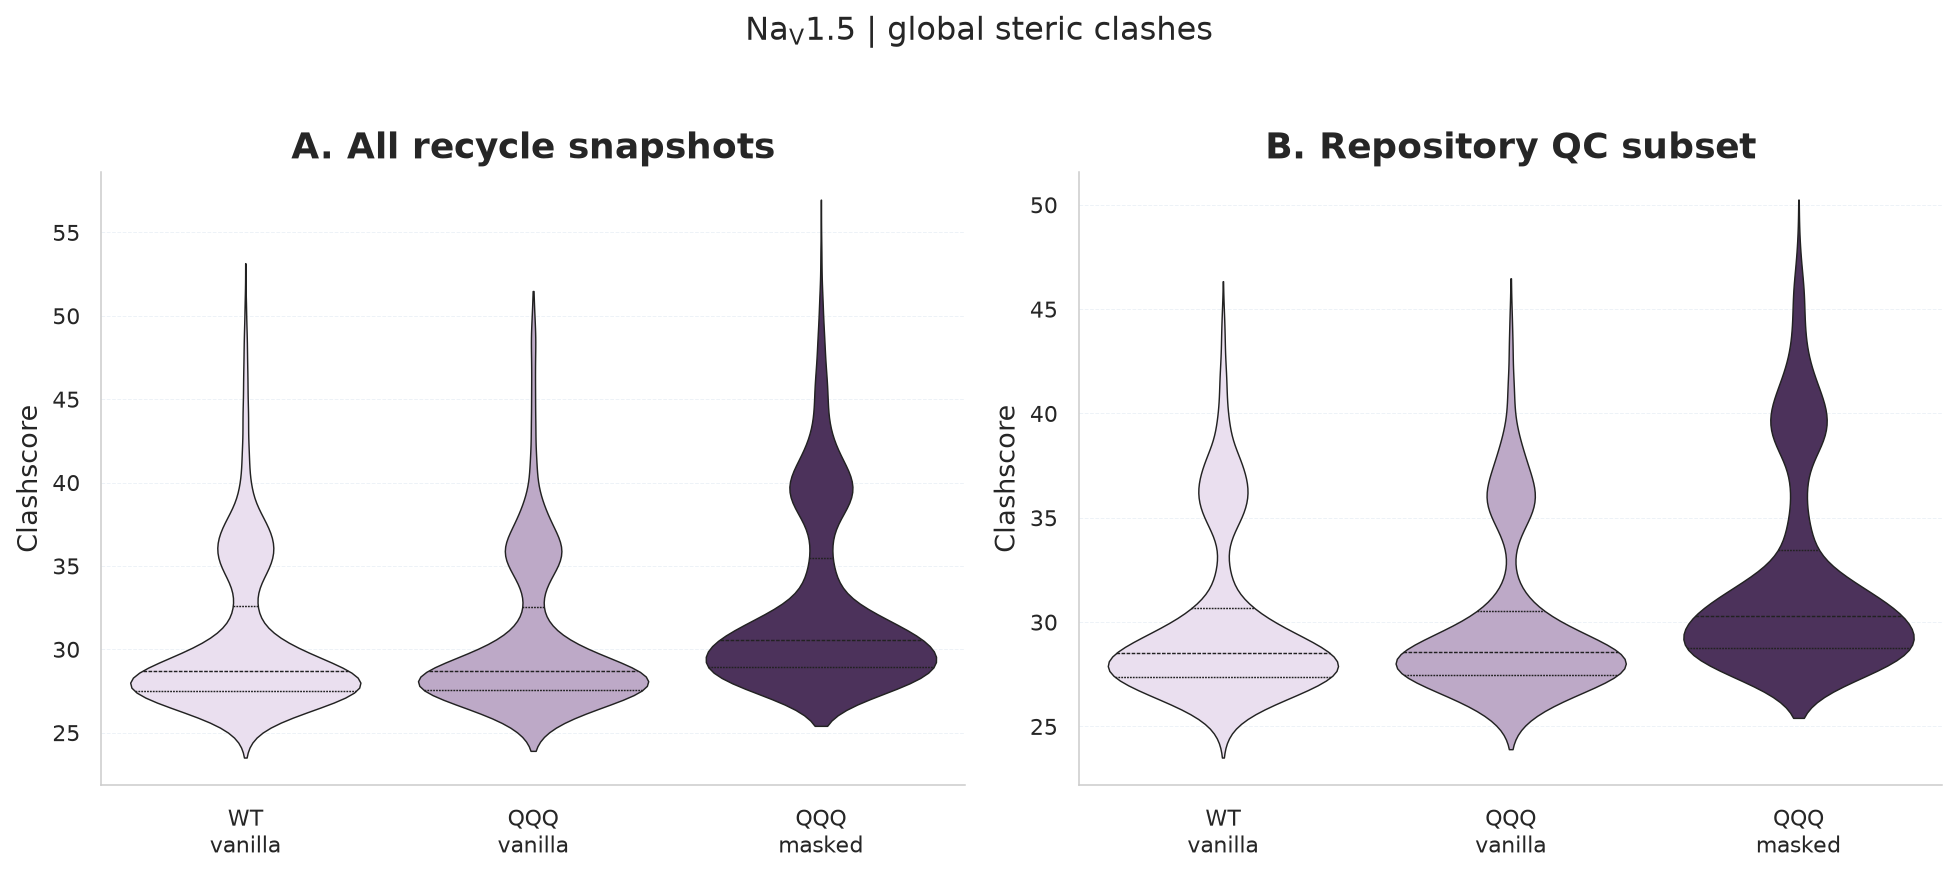

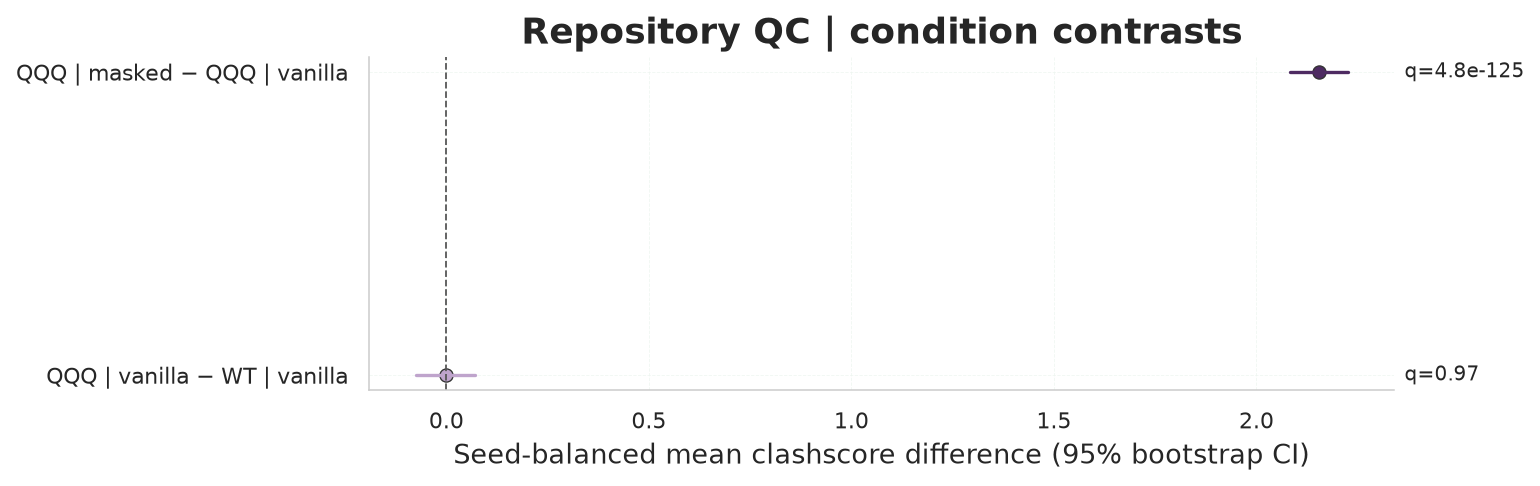

### Results on the repository QC subset

Model medians describe retained snapshots. Differences and confidence intervals below use equal AF-model weights within seed and seed-level inference.
- **WT | masked versus WT | vanilla:** model medians 30.38 versus 28.52 (Δ +1.86); seed-balanced mean Δ +2.17, 95% CI [2.09, 2.24]; seed rank-biserial effect +1.00; BH q=1.08e-122.
- **WT | masked v2 versus WT | vanilla:** model medians 29.79 versus 28.52 (Δ +1.27); seed-balanced mean Δ +1.74, 95% CI [1.67, 1.81]; seed rank-biserial effect +1.00; BH q=2.24e-109.
- **WT | masked v2 no-IFM versus WT | vanilla:** model medians 29.75 versus 28.52 (Δ +1.23); seed-balanced mean Δ +1.71, 95% CI [1.65, 1.79]; seed rank-biserial effect +1.00; BH q=2.24e-109.
- **QQQ | masked versus QQQ | vanilla:** model medians 30.31 versus 28.56 (Δ +1.75); seed-balanced mean Δ +2.16, 95% CI [2.08, 2.23]; seed rank-biserial effect +1.00; BH q=4.82e-125.
- **QQQ | masked v2 versus QQQ | vanilla:** model medians 29.55 versus 28.56 (Δ +0.99); seed-balanced mean Δ +1.55, 95% CI [1.48, 1.62]; seed rank-biserial effect +1.00; BH q=7.61e-100.
- **QQQ | vanilla versus WT | vanilla:** model medians 28.56 versus 28.52 (Δ +0.04); seed-balanced mean Δ -0.00, 95% CI [-0.08, 0.07]; seed rank-biserial effect +0.01; BH q=0.966.
- **QQQ | masked versus WT | masked:** model medians 30.31 versus 30.38 (Δ -0.07); seed-balanced mean Δ -0.01, 95% CI [-0.09, 0.07]; seed rank-biserial effect -0.03; BH q=0.811.
- **QQQ | masked v2 versus WT | masked v2:** model medians 29.55 versus 29.79 (Δ -0.24); seed-balanced mean Δ -0.18, 95% CI [-0.26, -0.11]; seed rank-biserial effect -0.39; BH q=2.61e-06.
- **QQQ | masked v2 versus QQQ | masked:** model medians 29.55 versus 30.31 (Δ -0.76); seed-balanced mean Δ -0.60, 95% CI [-0.66, -0.54]; seed rank-biserial effect -0.92; BH q=1.42e-34.
- **WT | masked v2 versus WT | masked:** model medians 29.79 versus 30.38 (Δ -0.59); seed-balanced mean Δ -0.43, 95% CI [-0.49, -0.37]; seed rank-biserial effect -0.74; BH q=7.82e-27.
- **WT | masked v2 no-IFM versus WT | masked v2:** model medians 29.75 versus 29.79 (Δ -0.04); seed-balanced mean Δ -0.02, 95% CI [-0.05, 0.01]; seed rank-biserial effect -0.06; BH q=0.209.

In [5]:
mp.plot_distributions(cohorts, CHANNEL, OUT)
plt.show()
mp.plot_effects(contrasts, CHANNEL, OUT)
plt.show()
display(Markdown(mp.interpretation(summary, contrasts, CHANNEL)))


## Complementary steric diagnostics
These panels use the repository QC subset. Counts depend on structure size and atom handling; maximum overlap reports one extreme contact. Full numerical results and corrected comparisons for both metrics are retained alongside clashscore.

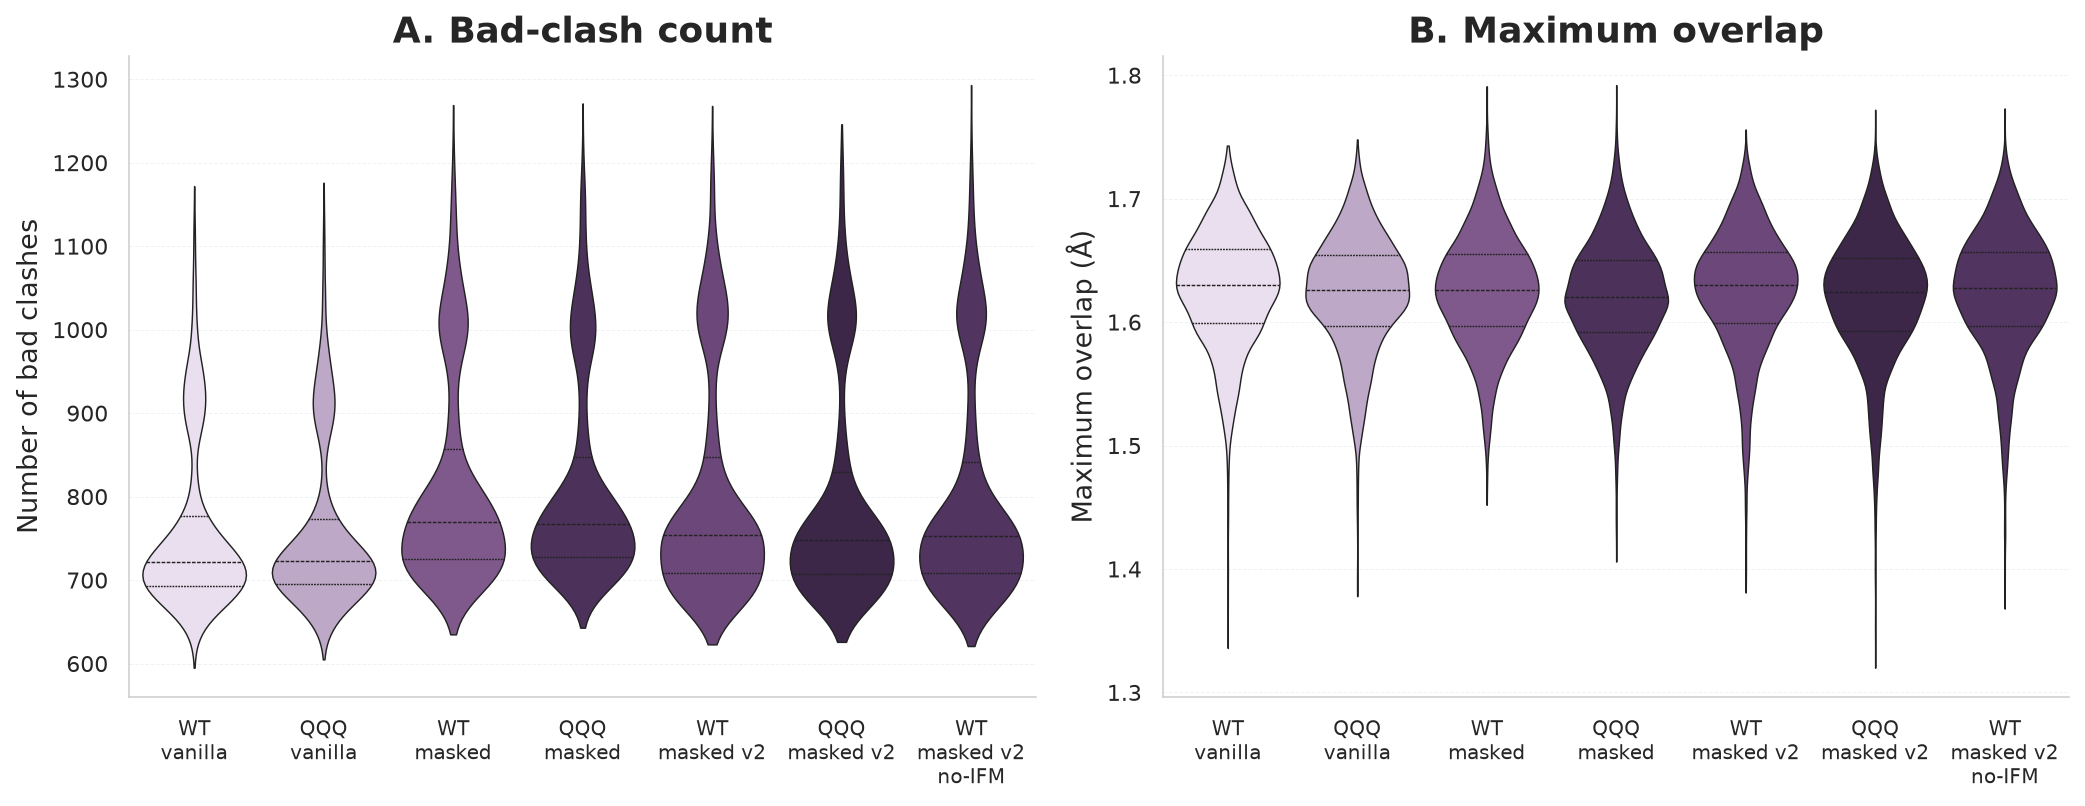

,cohort,ensemble,metric,N,n_seeds,median,Q1,Q3,IQR,mean,SD,minimum,maximum
64,repository_QC,QQQ | masked,n_bad_clashes,4999,100,767.000,728.000,847.000,119.000,813.513,123.352,643.000,1271.000
65,repository_QC,QQQ | masked,max_overlap,4999,100,1.620,1.592,1.650,0.058,1.620,0.046,1.406,1.792
67,repository_QC,QQQ | masked v2,n_bad_clashes,5000,100,748.000,707.000,829.000,122.000,798.313,133.023,626.000,1246.000
68,repository_QC,QQQ | masked v2,max_overlap,5000,100,1.624,1.593,1.652,0.059,1.619,0.051,1.320,1.772
70,repository_QC,QQQ | vanilla,n_bad_clashes,5000,100,723.000,695.000,773.000,78.000,758.952,99.522,605.000,1176.000
71,repository_QC,QQQ | vanilla,max_overlap,5000,100,1.626,1.597,1.654,0.057,1.623,0.047,1.378,1.748
73,repository_QC,WT | masked,n_bad_clashes,5000,100,769.000,725.000,857.000,132.000,813.968,125.203,635.000,1269.000
74,repository_QC,WT | masked,max_overlap,5000,100,1.626,1.597,1.655,0.058,1.625,0.045,1.452,1.791
76,repository_QC,WT | masked v2,n_bad_clashes,4999,100,754.000,709.000,848.000,139.000,803.139,133.469,623.000,1268.000
77,repository_QC,WT | masked v2,max_overlap,4999,100,1.630,1.599,1.657,0.058,1.625,0.049,1.381,1.756


,A,B,metric,median_difference,seed_mean_difference,CI_low,CI_high,seed_rank_biserial,q_BH
34,WT | vanilla,WT | masked,n_bad_clashes,47.000,54.8182,52.9398,56.7124,1.0000,0.0000
35,WT | vanilla,WT | masked,max_overlap,-0.004,-0.0011,-0.0030,0.0008,-0.1068,0.3089
37,WT | vanilla,WT | masked v2,n_bad_clashes,32.000,43.9822,42.2083,45.7070,1.0000,0.0000
38,WT | vanilla,WT | masked v2,max_overlap,0.000,-0.0016,-0.0034,0.0003,-0.1466,0.1542
40,WT | vanilla,WT | masked v2 no-IFM,n_bad_clashes,31.000,43.4144,41.7392,45.2072,1.0000,0.0000
41,WT | vanilla,WT | masked v2 no-IFM,max_overlap,-0.002,-0.0025,-0.0044,-0.0006,-0.2251,0.0228
43,QQQ | vanilla,QQQ | masked,n_bad_clashes,44.000,54.5571,52.7265,56.3248,1.0000,0.0000
44,QQQ | vanilla,QQQ | masked,max_overlap,-0.006,-0.0027,-0.0043,-0.0010,-0.2521,0.0042
46,QQQ | vanilla,QQQ | masked v2,n_bad_clashes,25.000,39.3612,37.4557,41.1027,1.0000,0.0000
47,QQQ | vanilla,QQQ | masked v2,max_overlap,-0.002,-0.0033,-0.0051,-0.0013,-0.2652,0.0013


In [6]:
mp.plot_diagnostics(cohorts, CHANNEL, OUT)
plt.show()
display(summary[(summary.cohort=='repository_QC') & summary.metric.ne('clashscore')].round(3))
display(contrasts[(contrasts.cohort=='repository_QC') & contrasts.metric.ne('clashscore')][
    ['A','B','metric','median_difference','seed_mean_difference','CI_low','CI_high','seed_rank_biserial','q_BH']].round(4))


## Supplementary mask-design controls
All seven ensembles are retained here. Compare the original mask with v2 within sequence, and WT masked v2 with WT masked v2 no-IFM. These controls test sensitivity to mask design.

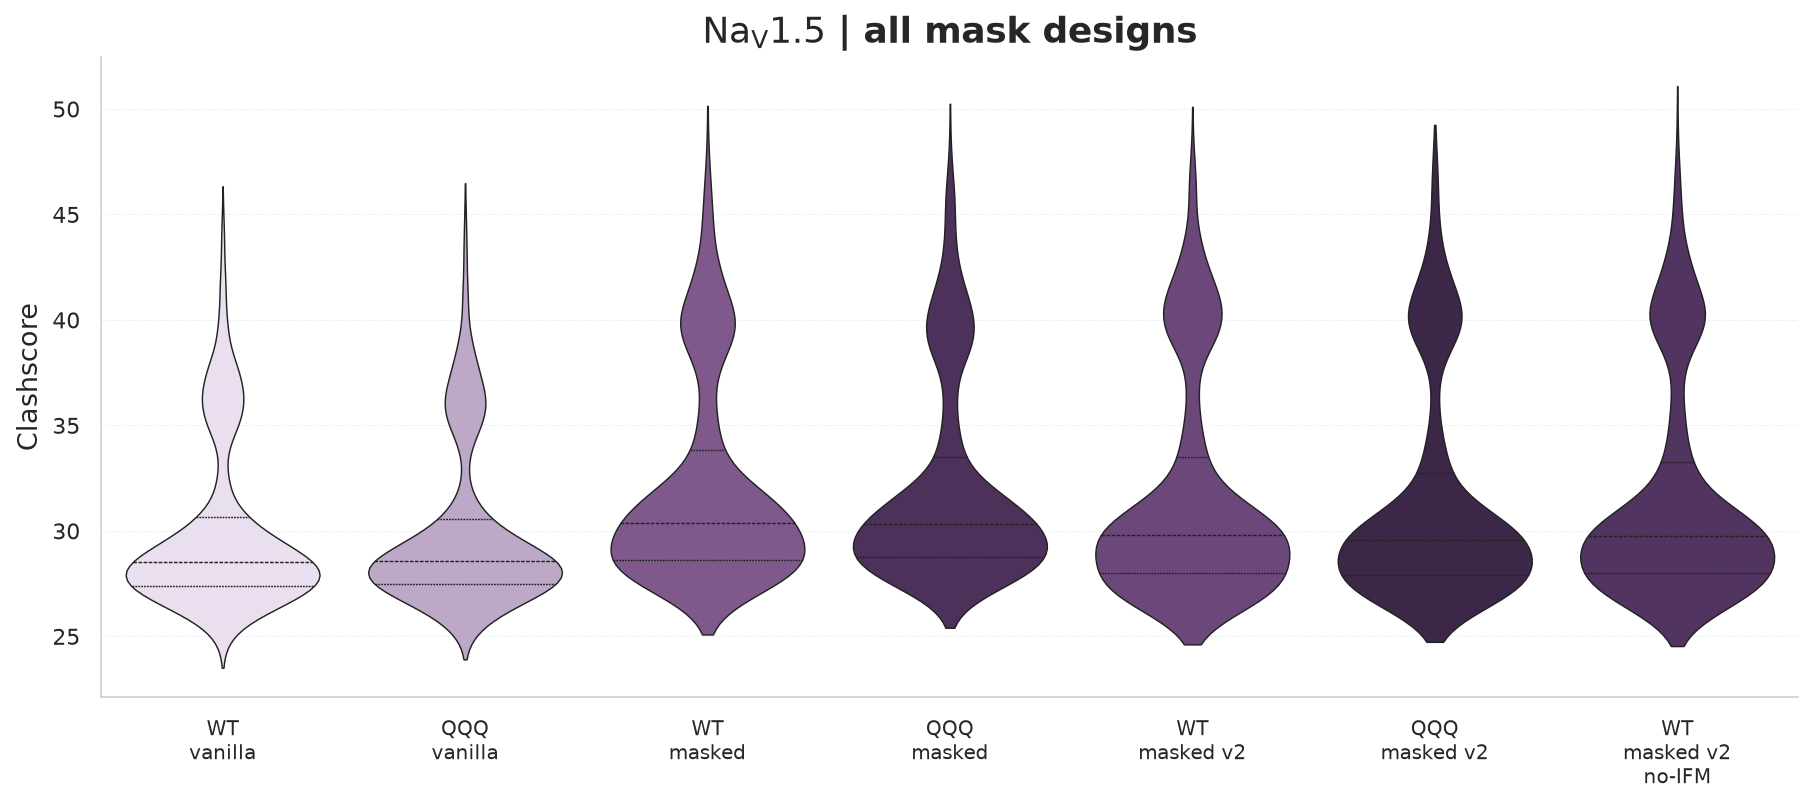

In [7]:
mp.plot_nav_controls(cohorts, OUT)
plt.show()

## Recycle, AF-model, seed, and rank sensitivity
The full snapshot trace includes final separately and all early-recycle tails. The final-only analysis does not substitute a last available snapshot for a missing final file. The adjusted regression controls AF-model and snapshot composition, with uncertainty clustered by seed; its observation-weighted estimand differs from the seed-balanced primary result.

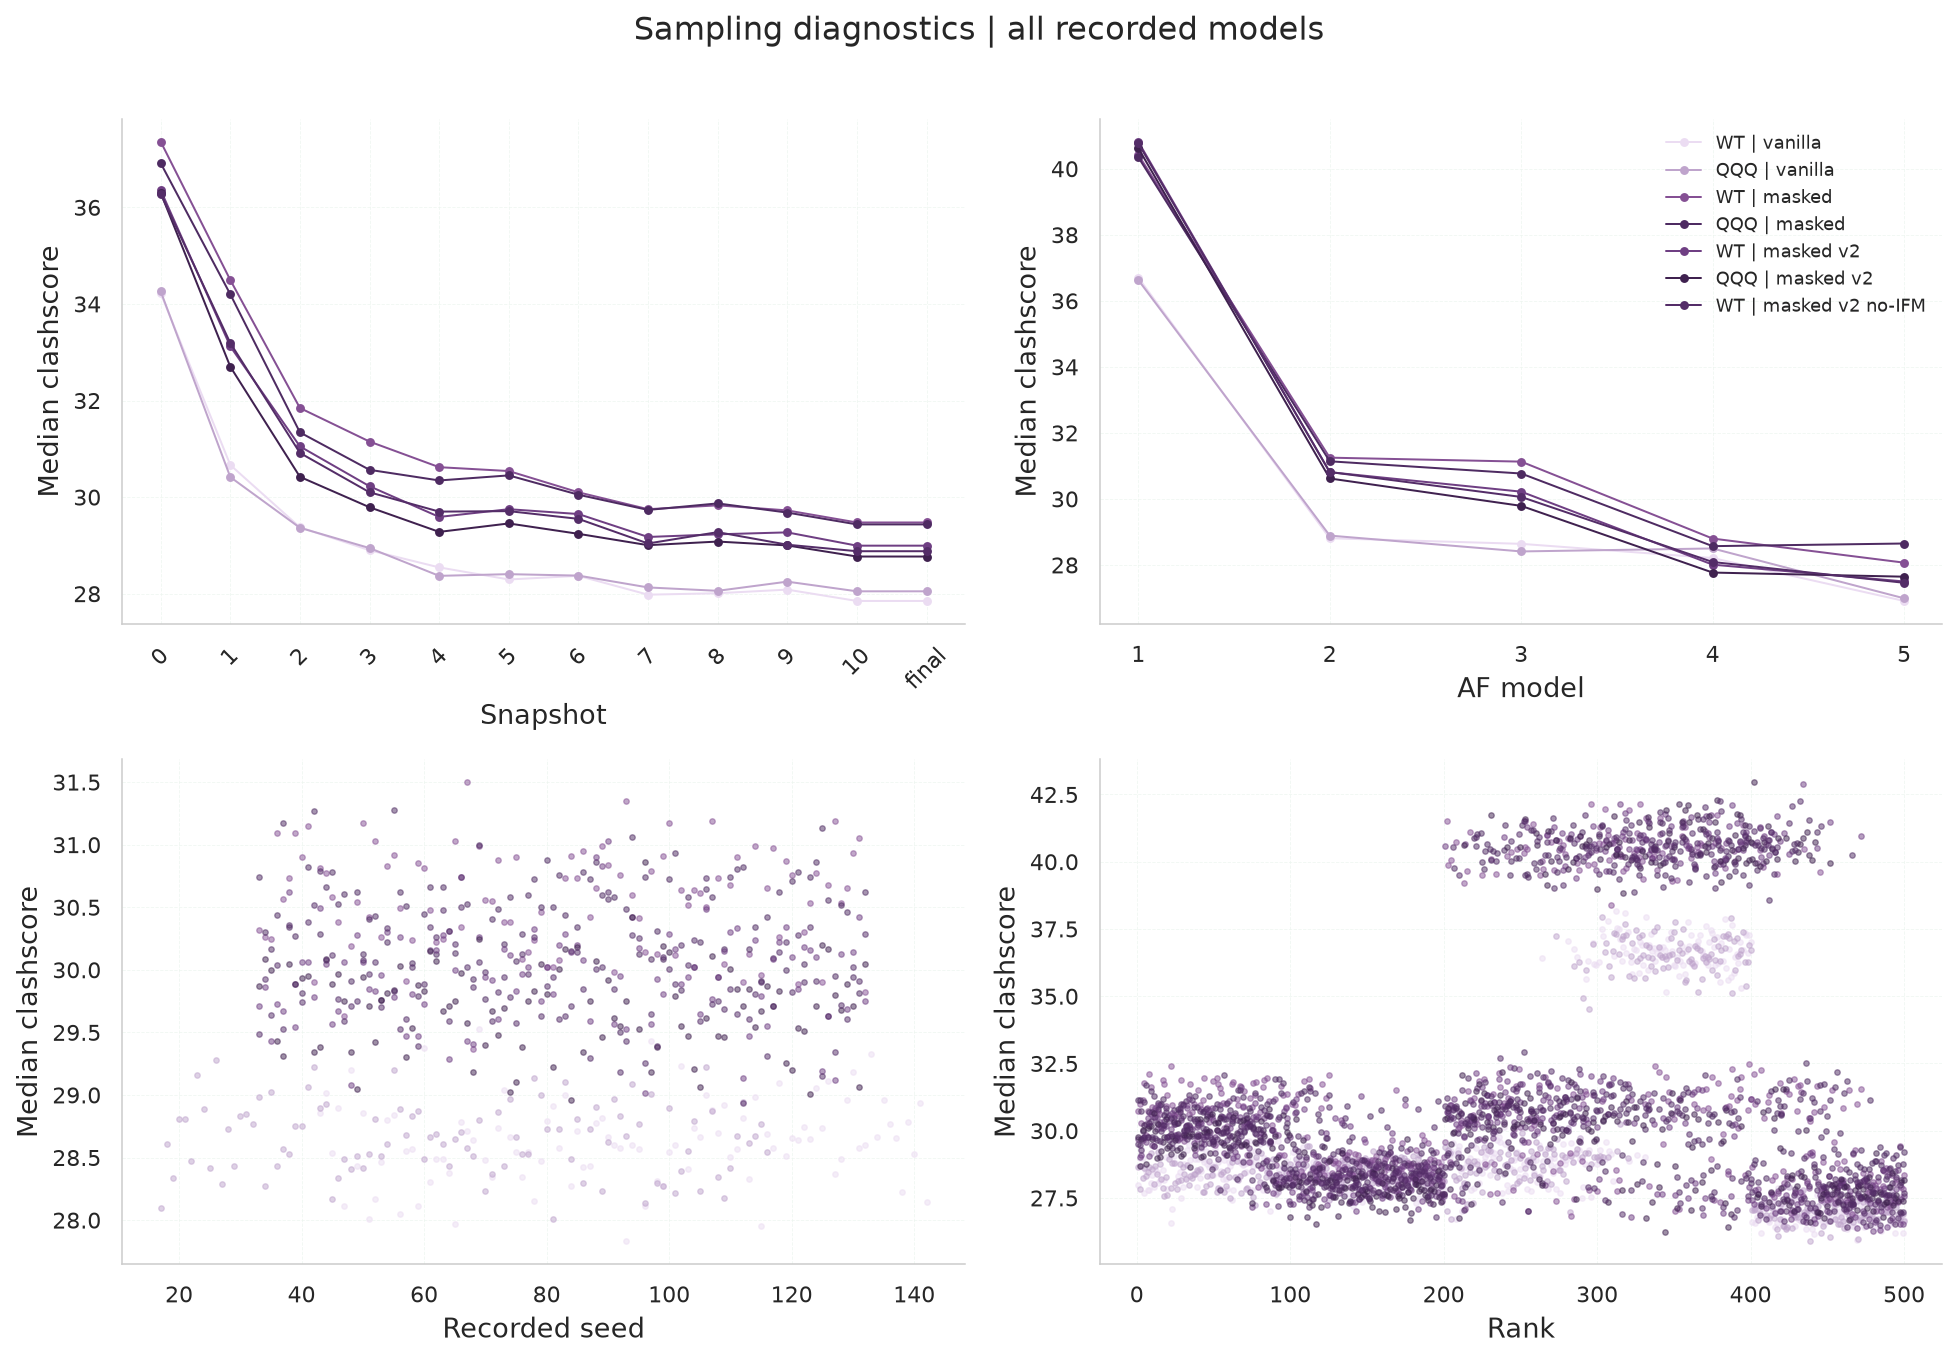

,A,B,adjusted_difference,CI_low,CI_high,p,q_BH
0,WT | vanilla,WT | masked,2.1657,2.1010,2.2305,0.0000,0.0000
1,WT | vanilla,WT | masked v2,1.7377,1.6763,1.7992,0.0000,0.0000
2,WT | vanilla,WT | masked v2 no-IFM,1.7146,1.6552,1.7741,0.0000,0.0000
3,QQQ | vanilla,QQQ | masked,2.1558,2.0895,2.2222,0.0000,0.0000
4,QQQ | vanilla,QQQ | masked v2,1.5544,1.4930,1.6158,0.0000,0.0000
5,WT | vanilla,QQQ | vanilla,-0.0016,-0.0730,0.0698,0.9649,0.9649
6,WT | masked,QQQ | masked,-0.0113,-0.0895,0.0668,0.7760,0.8536
7,WT | masked v2,QQQ | masked v2,-0.1851,-0.2555,-0.1147,0.0000,0.0000
8,QQQ | masked,QQQ | masked v2,-0.6016,-0.6633,-0.5398,0.0000,0.0000
9,WT | masked,WT | masked v2,-0.4278,-0.4838,-0.3718,0.0000,0.0000


AF_model                                                     1      2      3  \
A              B                     mode                                      
QQQ | masked   QQQ | masked v2       leave_AF_model_out -0.813 -0.651 -0.474   
                                     only_AF_model       0.247 -0.398 -1.110   
QQQ | vanilla  QQQ | masked          leave_AF_model_out  1.745  2.072  2.042   
                                     only_AF_model       3.795  2.488  2.609   
               QQQ | masked v2       leave_AF_model_out  0.932  1.421  1.568   
                                     only_AF_model       4.043  2.089  1.499   
WT | masked    QQQ | masked          leave_AF_model_out -0.002  0.015  0.052   
                                     only_AF_model      -0.051 -0.120 -0.270   
               WT | masked v2        leave_AF_model_out -0.603 -0.504 -0.294   
                                     only_AF_model       0.269 -0.128 -0.969   
WT | masked v2 QQQ | masked v2       leave_AF_model_out -0.212 -0.133 -0.128   
                                     only_AF_model      -0.073 -0.391 -0.411   
               WT | masked v2 no-IFM leave_AF_model_out -0.028  0.003 -0.006   
                                     only_AF_model       0.001 -0.124 -0.089   
WT | vanilla   QQQ | vanilla         leave_AF_model_out  0.023 -0.029  0.059   
                                     only_AF_model      -0.102  0.109 -0.244   
               WT | masked           leave_AF_model_out  1.771  2.028  2.049   
                                     only_AF_model       3.745  2.717  2.634   
               WT | masked v2        leave_AF_model_out  1.168  1.524  1.755   
                                     only_AF_model       4.014  2.589  1.665   
               WT | masked v2 no-IFM leave_AF_model_out  1.140  1.527  1.749   
                                     only_AF_model       4.015  2.465  1.576   

AF_model                                                     4      5  
A              B                     mode                              
QQQ | masked   QQQ | masked v2       leave_AF_model_out -0.561 -0.505  
                                     only_AF_model      -0.760 -0.984  
QQQ | vanilla  QQQ | masked          leave_AF_model_out  2.654  2.263  
                                     only_AF_model       0.159  1.726  
               QQQ | masked v2       leave_AF_model_out  2.093  1.758  
                                     only_AF_model      -0.601  0.742  
WT | masked    QQQ | masked          leave_AF_model_out  0.037 -0.163  
                                     only_AF_model      -0.209  0.590  
               WT | masked v2        leave_AF_model_out -0.360 -0.383  
                                     only_AF_model      -0.705 -0.611  
WT | masked v2 QQQ | masked v2       leave_AF_model_out -0.164 -0.285  
                                     only_AF_model      -0.264  0.218  
               WT | masked v2 no-IFM leave_AF_model_out -0.056 -0.025  
                                     only_AF_model       0.113 -0.013  
WT | vanilla   QQQ | vanilla         leave_AF_model_out -0.047 -0.015  
                                     only_AF_model       0.178  0.051  
               WT | masked           leave_AF_model_out  2.571  2.410  
                                     only_AF_model       0.546  1.187  
               WT | masked v2        leave_AF_model_out  2.211  2.027  
                                     only_AF_model      -0.159  0.576  
               WT | masked v2 no-IFM leave_AF_model_out  2.155  2.003  
                                     only_AF_model      -0.046  0.563

,cohort,A,B,seed_mean_difference,CI_low,CI_high,q_BH
0,all_recycles,WT | vanilla,WT | masked,2.156,2.083,2.230,0.000
3,all_recycles,WT | vanilla,WT | masked v2,1.708,1.640,1.776,0.000
6,all_recycles,WT | vanilla,WT | masked v2 no-IFM,1.683,1.616,1.753,0.000
9,all_recycles,QQQ | vanilla,QQQ | masked,2.142,2.066,2.215,0.000
12,all_recycles,QQQ | vanilla,QQQ | masked v2,1.540,1.464,1.608,0.000
15,all_recycles,WT | vanilla,QQQ | vanilla,0.008,-0.067,0.082,0.937
18,all_recycles,WT | masked,QQQ | masked,-0.006,-0.083,0.071,0.937
21,all_recycles,WT | masked v2,QQQ | masked v2,-0.160,-0.231,-0.088,0.000
24,all_recycles,QQQ | masked,QQQ | masked v2,-0.602,-0.661,-0.540,0.000
27,all_recycles,WT | masked,WT | masked v2,-0.448,-0.503,-0.397,0.000


In [8]:
mp.stratification(cohorts, CHANNEL, OUT)
plt.show()
adjusted = mp.adjusted_contrasts(cohorts, CHANNEL, OUT)
display(adjusted.round(4))
af_sensitivity = mp.af_model_sensitivity(cohorts, CHANNEL, OUT)
display(af_sensitivity.pivot(index=['A','B','mode'], columns='AF_model', values='seed_mean_difference').round(3))
display(contrasts[contrasts.metric.eq('clashscore')][
    ['cohort','A','B','seed_mean_difference','CI_low','CI_high','q_BH']].round(3))


## Focused interpretation
The following text is generated from the executed result tables so it stays synchronized with reruns.

In [9]:
display(Markdown(mp.focused_interpretation(summary, contrasts, CHANNEL, OUT)))

**Primary sequence versus mask comparison.** WT vanilla and QQQ vanilla medians are 28.52 and 28.56; seed-balanced QQQ−WT is -0.002 (95% CI -0.075 to +0.072). QQQ masking raises the median to 30.31, with a seed-balanced change of +2.155 (95% CI +2.083 to +2.225).

QQQ masked v2 versus original masked changes the mean by -0.601 (95% CI -0.661 to -0.540). The WT no-IFM control versus WT masked v2 changes it by -0.022 (95% CI -0.053 to +0.009).

The principal global difference follows mask design, not the QQQ substitution under vanilla. Maximum-overlap medians remain close across the ensembles; there is no unique catastrophic global-quality outlier among the retained conditions. This is a relative QC statement, not certification of atomistic quality in these unrelaxed models. The mask-related clashscore cost is useful alongside the pore-sampling figures; most alternative-mask results belong in supplementary QC.

**AF-model dependence.** The following ranges are effect magnitudes, not new hypothesis tests:

- WT masked−vanilla: individual AF-model mean differences range from +0.55 to +3.75; leaving out one AF model at a time gives +1.77 to +2.57.

- QQQ masked−vanilla: individual AF-model mean differences range from +0.16 to +3.80; leaving out one AF model at a time gives +1.75 to +2.65.

Original masking raises the mean within every AF-model stratum. The stratified tables and final-r10 sensitivities should accompany claims based on pooled means.

## Reproducibility record
All generated outputs are confined to this channel’s `dataExtra/molprobity/{tables,figures}`. Existing figures and analyses are not overwritten. Input hashes, missing-model lists, full descriptive/contrast tables, pairing diagnostics and sensitivity results accompany the figures.

In [10]:
record = {'channel': CHANNEL, 'total_downloaded_csvs': total_csv_files,
          'channel_csvs': len(inventory), 'rows': len(raw), 'python': platform.python_version(),
          'bootstrap_replicates': mp.BOOTSTRAPS, 'random_seed': mp.RANDOM_SEED,
          'packages': {p: importlib.metadata.version(p) for p in ['numpy','pandas','scipy','statsmodels','matplotlib','seaborn']}}
(OUT/'tables/run_metadata.json').write_text(json.dumps(record, indent=2)+chr(10))
print('Completed:', OUT.relative_to(ROOT))


Completed: nav15/dataExtra/molprobity
